In [1]:
# import libraries

import pandas as pd
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
print("Imports Successful!")


Imports Successful!


## Boulder

In [ ]:
# Create an API call to the NOAA NCEI database
ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1' #go to this website
           '?dataset=daily-summaries'   #get the daily summaries
           '&dataTypes=TOBS'   #get the data type for Total obs
           '&stations=USC00050848'  #use the station code for that station in Boulder, can change this as needed (and dates below)
           '&startDate=1893-10-01'  #specify the start and end dates
           '&endDate=2026-07-15'
           '&units=standard') #use standard units
ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00050848&startDate=1893-10-01&endDate=2026-07-15&units=standard'

In [ ]:
# now create a dataframe
# Open and clean the data
boulder_df = pd.read_csv(  #use pandas to read a csv file, use the data from the ncei_url
    ncei_url,
    na_values=["-99"],  #make any "-99"s into NAs
    index_col="DATE", #index on the date
    parse_dates=["DATE"]  #make columns based on the date
)
boulder_df
   #46990 rows, TObs is temp in F

,STATION,TOBS
DATE,,
1893-10-01,USC00050848,NaN
1893-10-02,USC00050848,NaN
1893-10-03,USC00050848,NaN
1893-10-04,USC00050848,NaN
1893-10-05,USC00050848,NaN
...,...,...
2026-07-11,USC00050848,91.0
2026-07-12,USC00050848,95.0
2026-07-13,USC00050848,95.0


In [6]:
#Clean data
#take out the Station Column
boulder_df = boulder_df[["TOBS"]]
boulder_df.head()
boulder_df.tail()


,TOBS
DATE,
2026-07-11,91.0
2026-07-12,95.0
2026-07-13,95.0
2026-07-14,95.0
2026-07-15,90.0


### Plot

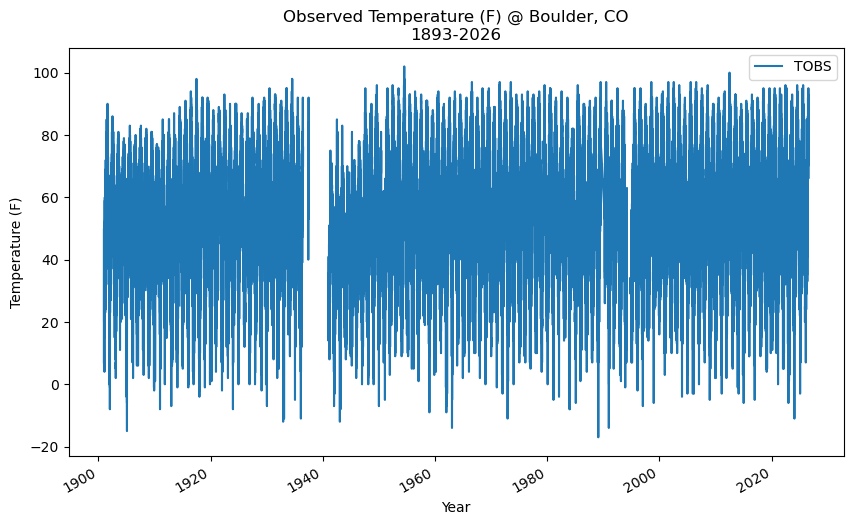

In [ ]:
#plot
# Plot data with matplotlib
fig, ax = plt.subplots(figsize=(10,6))
boulder_df.plot(y='TOBS',
                 ax=ax,
                 ylabel='Temperature (F)',
                 xlabel='Year',
                 title='Observed Temperature (F) @ Boulder, CO\n1893-2026')
plt.show()

  #very busy

### Annual Temp And Plot

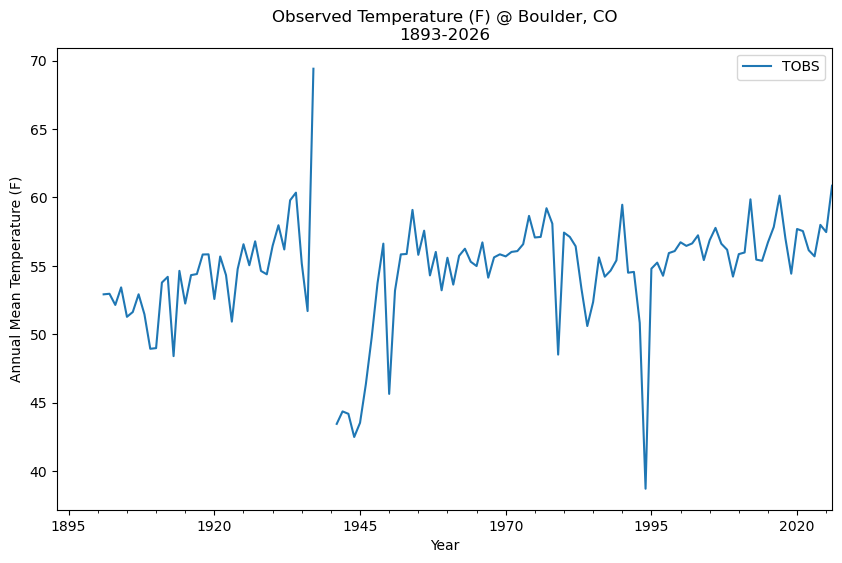

In [14]:
#take annual mean temp
annual_climate_df = boulder_df.resample('YE').mean()  #make new df that pulls the means from boulder.df
annual_climate_df

#plot

fig, ax = plt.subplots(figsize=(10,6))
annual_climate_df.plot(y='TOBS',
                 ax=ax,
                 ylabel='Annual Mean Temperature (F)',
                 xlabel='Year',
                 title='Observed Temperature (F) @ Boulder, CO\n1893-2026')
plt.show()


<Axes: xlabel='DATE'>

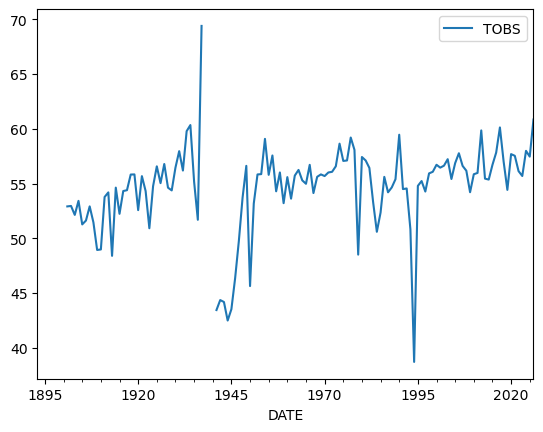

In [15]:
annual_climate_df.plot()

<Axes: xlabel='DATE'>

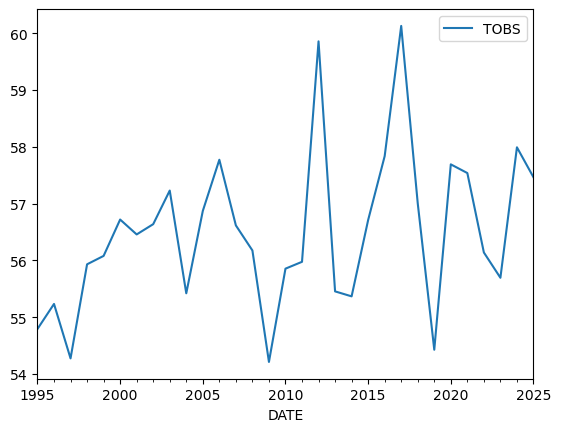

In [ ]:
# Subset the data to look at last 30 years of data
boulder_30yr = annual_climate_df.loc["1995":"2025"]  #.loc means look at this location, it's like $ in R
boulder_30yr


boulder_30yr.plot()

In [ ]:
#test--not working
boulder_30yr_july = annual_climate_df.loc["1995-07":"2025-07"]  #.loc means look at this location, it's like $ in R
boulder_30yr_july


,TOBS
DATE,
1995-12-31,54.792818
1996-12-31,55.233516
1997-12-31,54.274725
1998-12-31,55.931507
1999-12-31,56.079452
2000-12-31,56.719780
2001-12-31,56.457534
2002-12-31,56.638356
2003-12-31,57.230137


In [20]:
# Create an interactive plot with hvplot
boulder_30yr_plot = boulder_30yr.hvplot()
boulder_30yr_plot

:Curve   [DATE]   (TOBS)

In [ ]:
# Save interactive plot as html to host on the web
hv.save(boulder_30yr_plot, 'boulder_plot.html')

#we downloaded this, and put it github website: crhawley/github.io

## SEDONA

In [29]:
# Create an API call to the NOAA NCEI database
ncei_url_sedona = ('https://www.ncei.noaa.gov/access/services/data/v1' #go to this website
           '?dataset=daily-summaries'   #get the daily summaries
           '&dataTypes=TOBS'   #get the data type for Total obs
           '&stations=USC00027708'  #use the station code for that station in Boulder, can change this as needed (and dates below)
           '&startDate=1943-10-20'  #specify the start and end dates
           '&endDate=2026-02-09'
           '&units=standard') #use standard units
ncei_url_sedona



'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00027708&startDate=1943-10-20&endDate=2026-02-09&units=standard'

### Dataframe

In [30]:
# now create a dataframe
# Open and clean the data
sedona_df = pd.read_csv(  #use pandas to read a csv file, use the data from the ncei_url
    ncei_url_sedona,
    na_values=["-99"],  #make any "-99"s into NAs
    index_col="DATE", #index on the date
    parse_dates=["DATE"]  #make columns based on the date
)
sedona_df
   #46990 rows, TObs is temp in F

,STATION,TOBS
DATE,,
1943-10-20,USC00027708,50.0
1943-10-21,USC00027708,59.0
1943-10-22,USC00027708,58.0
1943-10-23,USC00027708,59.0
1943-10-24,USC00027708,62.0
...,...,...
2026-01-28,USC00027708,54.0
2026-01-29,USC00027708,58.0
2026-01-30,USC00027708,60.0


### Clean Data

In [31]:
#Clean data
#take out the Station Column
sedona_df = sedona_df[["TOBS"]]
sedona_df.head()
sedona_df.tail()


,TOBS
DATE,
2026-01-28,54.0
2026-01-29,58.0
2026-01-30,60.0
2026-01-31,67.0
2026-02-09,67.0


### Plot With Full History

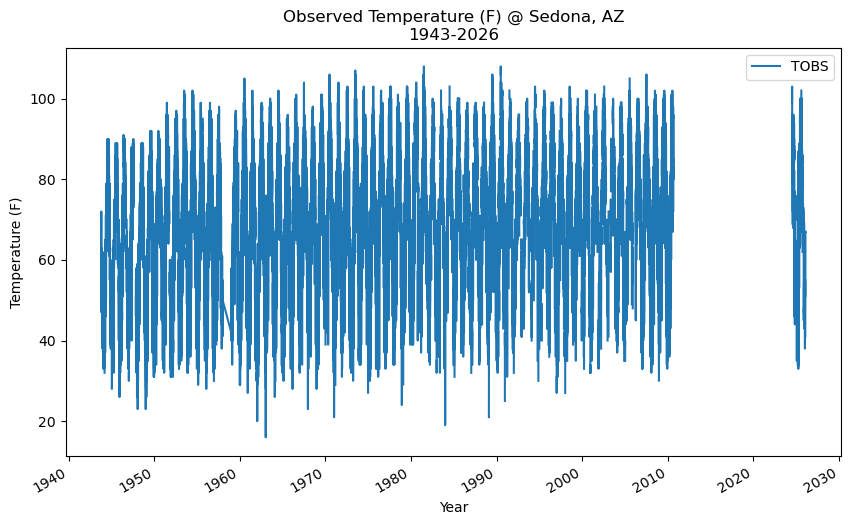

In [32]:
#plot
# Plot data with matplotlib
fig, ax = plt.subplots(figsize=(10,6))
sedona_df.plot(y='TOBS',
                 ax=ax,
                 ylabel='Temperature (F)',
                 xlabel='Year',
                 title='Observed Temperature (F) @ Sedona, AZ\n1943-2026')
plt.show()

  #very busy

### Subset and plot


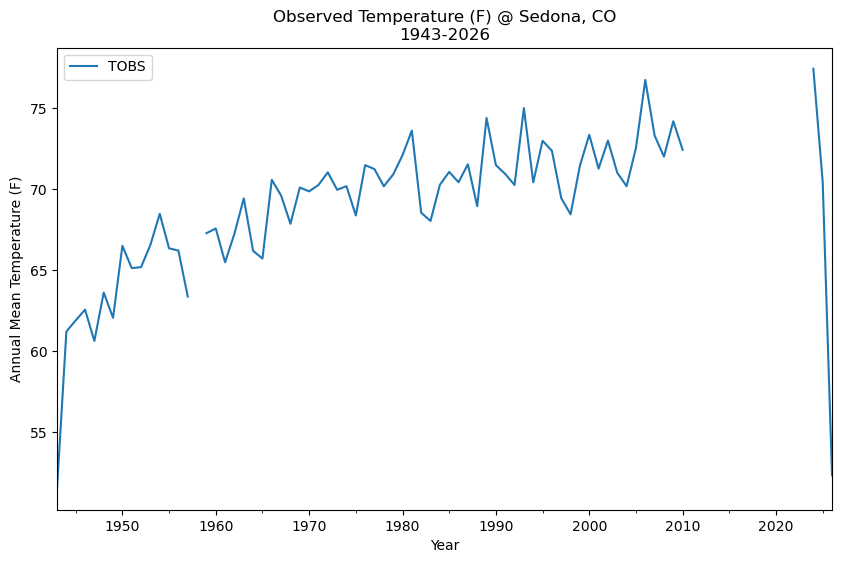

In [33]:
#take annual mean temp
annual_sedona = sedona_df.resample('YE').mean()  #make new df that pulls the means from boulder.df
annual_sedona

#plot

fig, ax = plt.subplots(figsize=(10,6))
annual_sedona.plot(y='TOBS',
                 ax=ax,
                 ylabel='Annual Mean Temperature (F)',
                 xlabel='Year',
                 title='Observed Temperature (F) @ Sedona, CO\n1943-2026')
plt.show()

### Save Plot

In [ ]:
#make an hv plot, interactive plot
sedona_annual_plot = annual_sedona.hvplot()

# Save interactive plot as html to host on the web
hv.save(sedona_annual_plot, 'sedona_annual_plot.html')